In [ ]:
pip install statsmodels

In [ ]:
from statsmodels.datasets import get_rdataset

In [ ]:
dataset = get_rdataset("AirPassengers")
dataset

<class 'statsmodels.datasets.utils.Dataset'>

In [ ]:
dir(dataset)

['__class__',
 '__class_getitem__',
 '__contains__',
 '__delattr__',
 '__delitem__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__ior__',
 '__iter__',
 '__le__',
 '__len__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__or__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__reversed__',
 '__ror__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 'clear',
 'copy',
 'data',
 'from_cache',
 'fromkeys',
 'get',
 'items',
 'keys',
 'package',
 'pop',
 'popitem',
 'raw_data',
 'setdefault',
 'title',
 'update',
 'values']

In [ ]:
data = dataset.data
data

,time,value
0,1949.000000,112
1,1949.083333,118
2,1949.166667,132
3,1949.250000,129
4,1949.333333,121
...,...,...
139,1960.583333,606
140,1960.666667,508
141,1960.750000,461
142,1960.833333,390


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 144 entries, 0 to 143
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   time    144 non-null    float64
 1   value   144 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 2.4 KB


In [ ]:
import pandas as pd

In [ ]:
help(pd.date_range)

Help on function date_range in module pandas.core.indexes.datetimes:

date_range(start=None, end=None, periods=None, freq=None, tz=None, normalize: 'bool' = False, name: 'Hashable | None' = None, inclusive: 'IntervalClosedType' = 'both', *, unit: 'str | None' = None, **kwargs) -> 'DatetimeIndex'
    Return a fixed frequency DatetimeIndex.

    Returns the range of equally spaced time points (where the difference between any
    two adjacent points is specified by the given frequency) such that they all
    satisfy `start <[=] x <[=] end`, where the first one and the last one are, resp.,
    the first and last time points in that range that fall on the boundary of ``freq``
    (if given as a frequency string) or that are valid for ``freq`` (if given as a
    :class:`pandas.tseries.offsets.DateOffset`). (If exactly one of ``start``,
    ``end``, or ``freq`` is *not* specified, this missing parameter can be computed
    given ``periods``, the number of timesteps in the range. See the note

In [ ]:
date = pd.date_range("1949-01", periods=len(data), freq='MS')
date

DatetimeIndex(['1949-01-01', '1949-02-01', '1949-03-01', '1949-04-01',
               '1949-05-01', '1949-06-01', '1949-07-01', '1949-08-01',
               '1949-09-01', '1949-10-01',
               ...
               '1960-03-01', '1960-04-01', '1960-05-01', '1960-06-01',
               '1960-07-01', '1960-08-01', '1960-09-01', '1960-10-01',
               '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', length=144, freq='MS')

In [ ]:
data['value'].values

array([112, 118, 132, 129, 121, 135, 148, 148, 136, 119, 104, 118, 115,
       126, 141, 135, 125, 149, 170, 170, 158, 133, 114, 140, 145, 150,
       178, 163, 172, 178, 199, 199, 184, 162, 146, 166, 171, 180, 193,
       181, 183, 218, 230, 242, 209, 191, 172, 194, 196, 196, 236, 235,
       229, 243, 264, 272, 237, 211, 180, 201, 204, 188, 235, 227, 234,
       264, 302, 293, 259, 229, 203, 229, 242, 233, 267, 269, 270, 315,
       364, 347, 312, 274, 237, 278, 284, 277, 317, 313, 318, 374, 413,
       405, 355, 306, 271, 306, 315, 301, 356, 348, 355, 422, 465, 467,
       404, 347, 305, 336, 340, 318, 362, 348, 363, 435, 491, 505, 404,
       359, 310, 337, 360, 342, 406, 396, 420, 472, 548, 559, 463, 407,
       362, 405, 417, 391, 419, 461, 472, 535, 622, 606, 508, 461, 390,
       432])

In [ ]:
passengers=pd.Series(data['value'].values, index=date)
passengers

,0
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461
1960-11-01,390


In [ ]:
import seaborn as sns
help(sns.lineplot)

Help on function lineplot in module seaborn.relational:

lineplot(data=None, *, x=None, y=None, hue=None, size=None, style=None, units=None, weights=None, palette=None, hue_order=None, hue_norm=None, sizes=None, size_order=None, size_norm=None, dashes=True, markers=None, style_order=None, estimator='mean', errorbar=('ci', 95), n_boot=1000, seed=None, orient='x', sort=True, err_style='band', err_kws=None, legend='auto', ci='deprecated', ax=None, **kwargs)
    Draw a line plot with possibility of several semantic groupings.

    The relationship between `x` and `y` can be shown for different subsets
    of the data using the `hue`, `size`, and `style` parameters. These
    parameters control what visual semantics are used to identify the different
    subsets. It is possible to show up to three dimensions independently by
    using all three semantic types, but this style of plot can be hard to
    interpret and is often ineffective. Using redundant semantics (i.e. both
    `hue` and `st

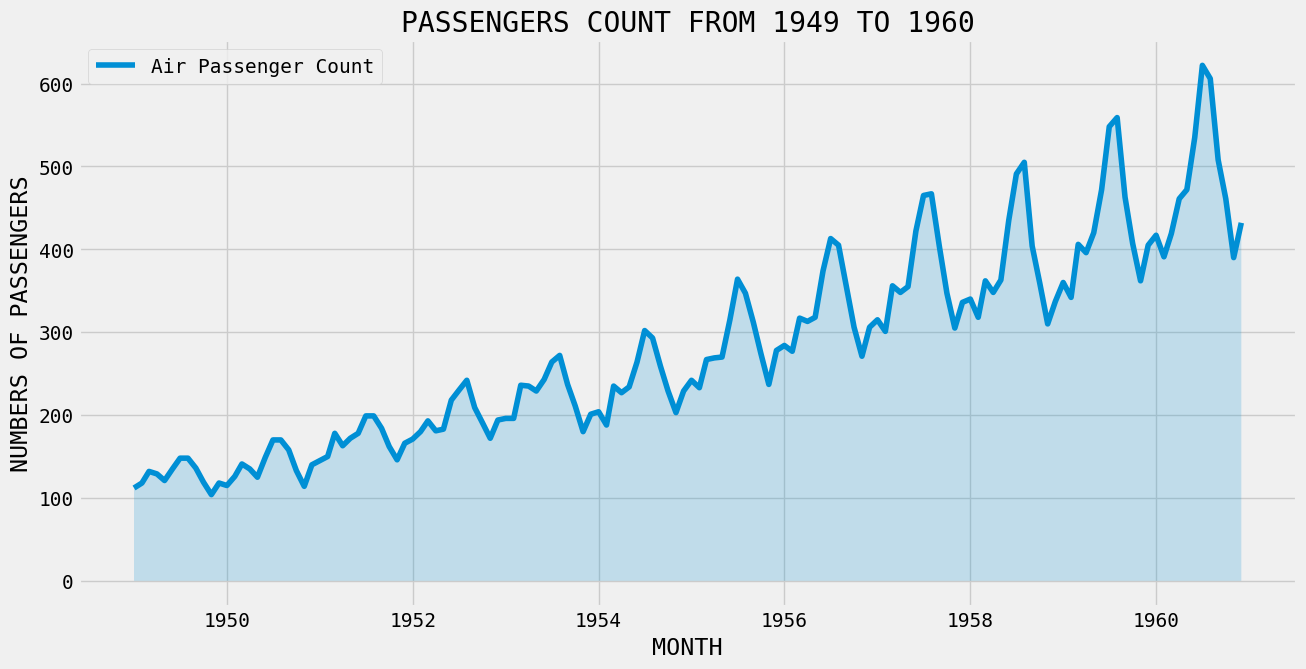

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('fivethirtyeight')
plt.rcParams['font.family'] = 'monospace'

fig, ax = plt.subplots(figsize=(14, 7))
sns.lineplot(x=passengers.index, y=passengers.values, ax=ax, label='Air Passenger Count')
ax.fill_between(passengers.index, passengers.values, alpha=0.2)
plt.title('PASSENGERS COUNT FROM 1949 TO 1960')
plt.xlabel('MONTH')
plt.ylabel('NUMBERS OF PASSENGERS')
plt.grid(True)
ax.legend(fontsize='medium') # Added legend with font size
plt.show()

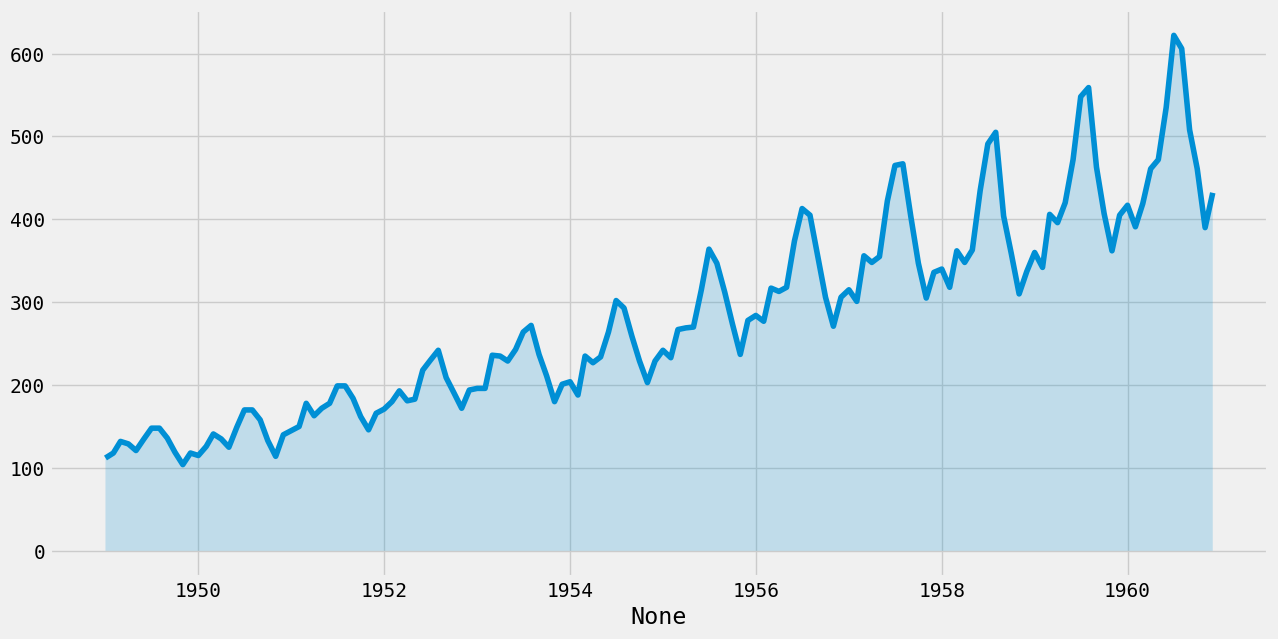

In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
sns.lineplot(x=passengers.index, y=passengers.values, ax=ax)
ax.fill_between(passengers.index, passengers.values, alpha=0.2)

# decomposition

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [ ]:
help(seasonal_decompose)

Help on function seasonal_decompose in module statsmodels.tsa.seasonal:

seasonal_decompose(x, model='additive', filt=None, period=None, two_sided=True, extrapolate_trend=0)
    Seasonal decomposition using moving averages.

    Parameters
    ----------
    x : array_like
        Time series. If 2d, individual series are in columns. x must contain 2
        complete cycles.
    model : {"additive", "multiplicative"}, optional
        Type of seasonal component. Abbreviations are accepted.
    filt : array_like, optional
        The filter coefficients for filtering out the seasonal component.
        The concrete moving average method used in filtering is determined by
        two_sided.
    period : int, optional
        Period of the series (e.g., 1 for annual, 4 for quarterly, etc). Must
        be used if x is not a pandas object or if the index of x does not have
        a frequency. Overrides default periodicity of x if x is a pandas
        object with a timeseries index.
    t

In [ ]:
decomposition = seasonal_decompose(passengers, model='multiplication', period=12)

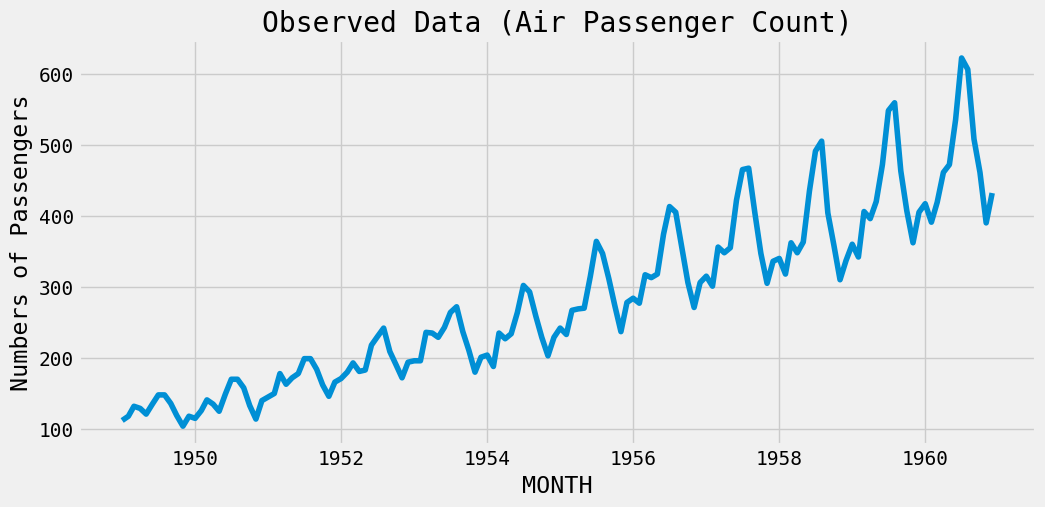

In [ ]:
plt.figure(figsize=(11, 5))
sns.lineplot(x=decomposition.observed.index, y=decomposition.observed.values)
plt.title('Observed Data (Air Passenger Count)')
plt.xlabel('MONTH')
plt.ylabel('Numbers of Passengers')
plt.grid(True)
plt.show()

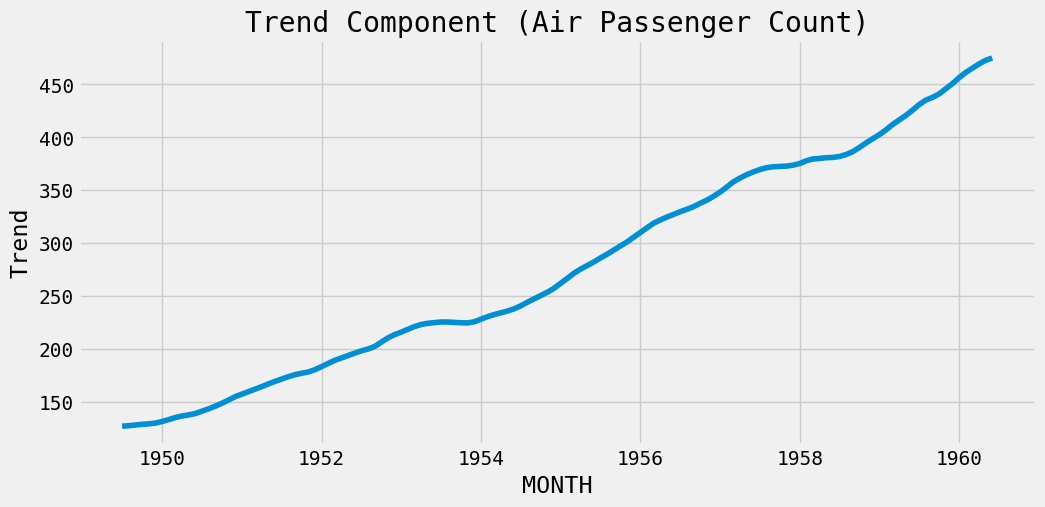

In [ ]:
plt.figure(figsize=(11, 5))
sns.lineplot(x=decomposition.trend.index, y=decomposition.trend.values)
plt.title('Trend Component (Air Passenger Count)')
plt.xlabel('MONTH')
plt.ylabel('Trend')
plt.grid(True)
plt.show()

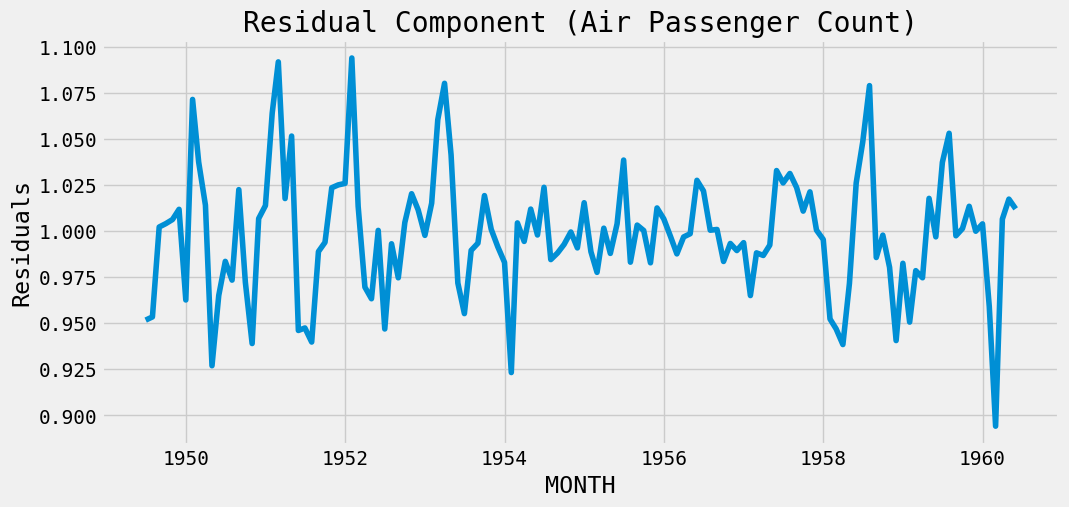

In [ ]:
plt.figure(figsize=(11, 5))
sns.lineplot(x=decomposition.resid.index, y=decomposition.resid.values)
plt.title('Residual Component (Air Passenger Count)')
plt.xlabel('MONTH')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

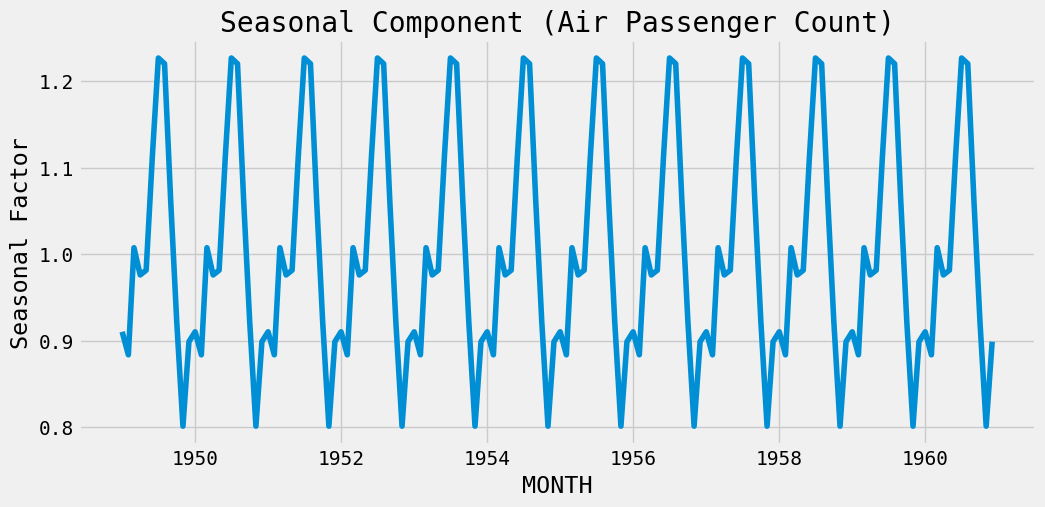

In [ ]:
plt.figure(figsize=(11,5))
sns.lineplot(x=decomposition.seasonal.index, y=decomposition.seasonal.values)
plt.title('Seasonal Component (Air Passenger Count)')
plt.xlabel('MONTH')
plt.ylabel('Seasonal Factor')
plt.grid(True)
plt.show()

In [ ]:
dir(decomposition)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_observed',
 '_resid',
 '_seasonal',
 '_trend',
 '_weights',
 'nobs',
 'observed',
 'plot',
 'resid',
 'seasonal',
 'trend',
 'weights']

#  checking for stationary

In [ ]:
from statsmodels.tsa.stattools import adfuller

In [ ]:
help(adfuller)

Help on function adfuller in module statsmodels.tsa.stattools:

adfuller(x, maxlag: 'int | None' = None, regression='c', autolag='AIC', store=False, regresults=False)
    Augmented Dickey-Fuller unit root test.

    The Augmented Dickey-Fuller test can be used to test for a unit root in a
    univariate process in the presence of serial correlation.

    Parameters
    ----------
    x : array_like, 1d
        The data series to test.
    maxlag : {None, int}
        Maximum lag which is included in test, default value of
        12*(nobs/100)^{1/4} is used when ``None``.
    regression : {"c","ct","ctt","n"}
        Constant and trend order to include in regression.

        * "c" : constant only (default).
        * "ct" : constant and trend.
        * "ctt" : constant, and linear and quadratic trend.
        * "n" : no constant, no trend.

    autolag : {"AIC", "BIC", "t-stat", None}
        Method to use when automatically determining the lag length among the
        values 0, 1, .

In [ ]:
stationary = adfuller(passengers)
stationary

(np.float64(0.8153688792060498),
 np.float64(0.991880243437641),
 13,
 130,
 {'1%': np.float64(-3.4816817173418295),
  '5%': np.float64(-2.8840418343195267),
  '10%': np.float64(-2.578770059171598)},
 np.float64(996.692930839019))

In [ ]:
p_value=stationary[1]
p_value

np.float64(0.991880243437641)

# CONVERTING NON STATIONARY INTO STATIONARY SERIES

### CONVERTING MULTIPLICATIVE TO ADDITIVE

In [ ]:
#log(x*y)= log(x)+log(y)

In [ ]:
import numpy as np

<Axes: xlabel='None'>

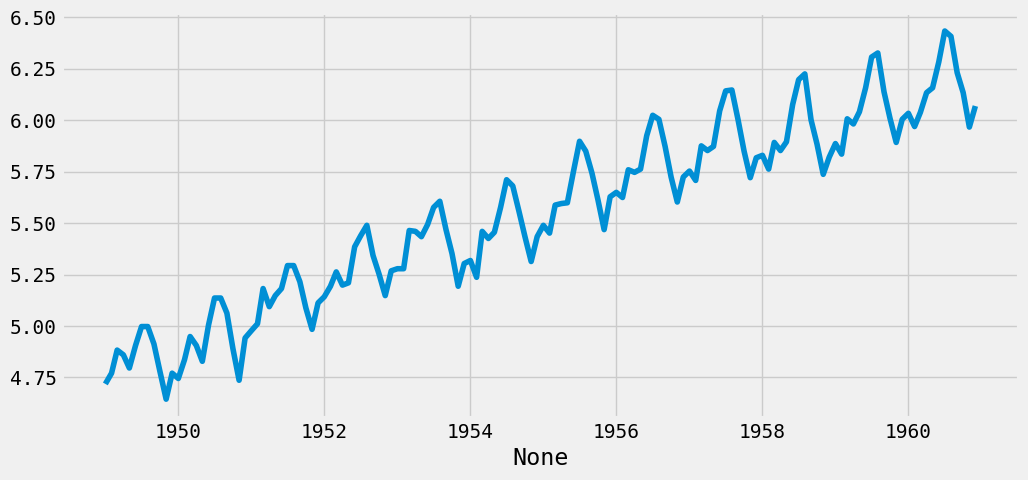

In [ ]:
fig, ax = plt.subplots(figsize=(11, 5))
sns.lineplot(x=passengers.index, y=np.log(passengers.values), ax=ax)

#removing seasonality

In [ ]:
passengers_log = np.log(passengers)
seasonality_removed = passengers_log.diff(12)
seasonality_removed

,0
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
...,...
1960-08-01,0.080731
1960-09-01,0.092754
1960-10-01,0.124585
1960-11-01,0.074503


Text(0.5, 0, 'MONTH/YEAR')

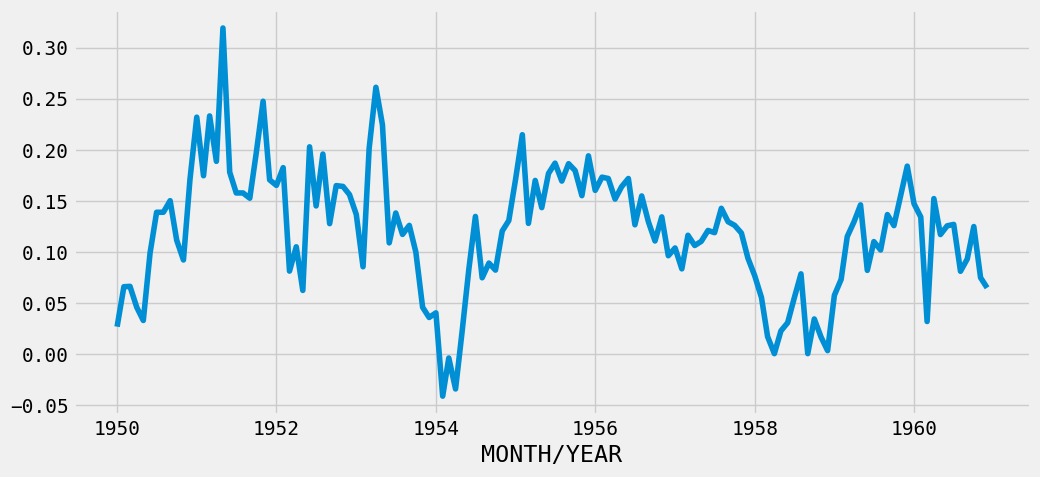

In [ ]:
fig,ax = plt.subplots(figsize=(11, 5))
sns.lineplot(x=seasonality_removed.index,y=seasonality_removed.values, ax=ax)
plt.xlabel("MONTH/YEAR")

###REMOVING TREND


In [ ]:
trend_remove = seasonality_removed.diff(1).dropna()
trend_remove

,0
1950-02-01,0.039164
1950-03-01,0.000361
1950-04-01,-0.020496
1950-05-01,-0.012939
1950-06-01,0.066148
...,...
1960-08-01,-0.045934
1960-09-01,0.012024
1960-10-01,0.031830
1960-11-01,-0.050082


Text(0.5, 0, 'MONTH/YEAR')

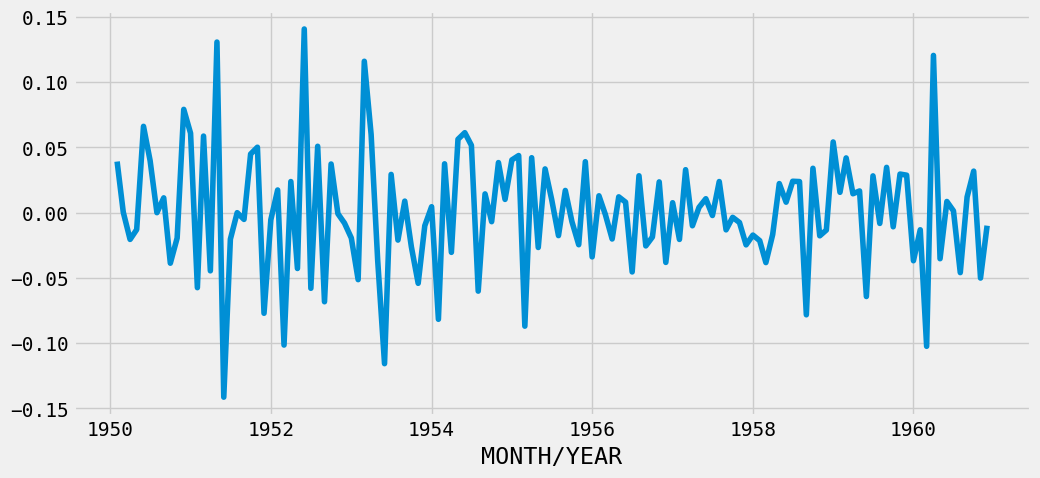

In [ ]:
fig,ax=plt.subplots(figsize=(11,5))
sns.lineplot(x=trend_remove.index, y=trend_remove.values, ax=ax)
plt.xlabel("MONTH/YEAR")

In [ ]:
stationary_trend_removed = adfuller(trend_remove)
p_value_trend_removed = stationary_trend_removed[1]
print(f"ADF Test P-value for trend_remove series: {p_value_trend_removed}")

ADF Test P-value for trend_remove series: 0.00024859123113838495


##AUTOCORRELATION:acf and pacf

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [ ]:
plot_pacf?

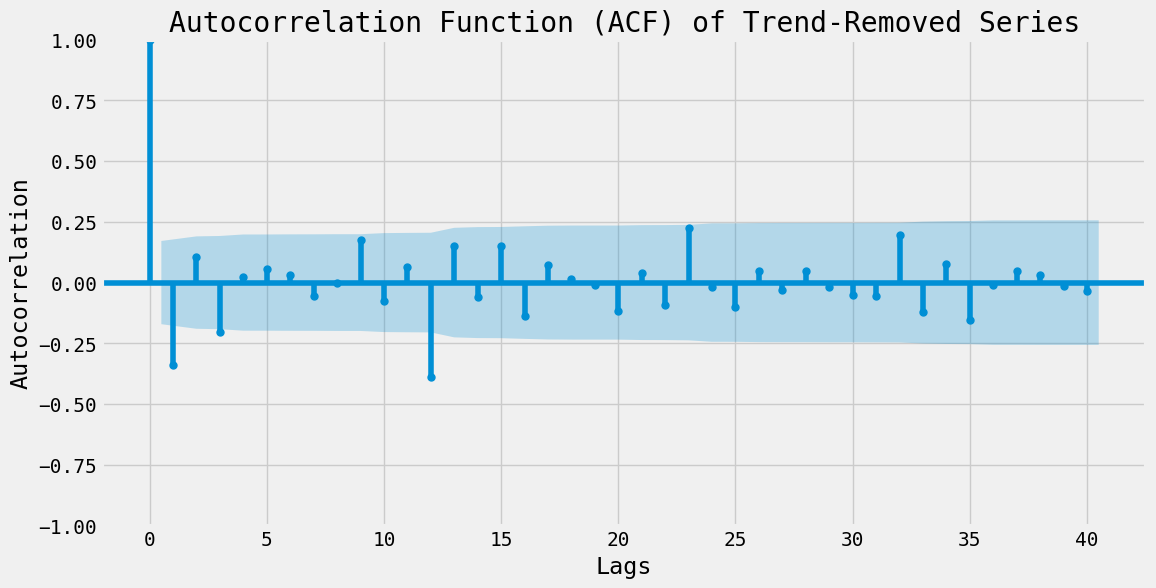

In [ ]:
plt.figure(figsize=(12, 6))
plot_acf(trend_remove, ax=plt.gca(), lags=40)
plt.title('Autocorrelation Function (ACF) of Trend-Removed Series')
plt.xlabel('Lags')
plt.ylabel('Autocorrelation')
plt.grid(True)
plt.show()

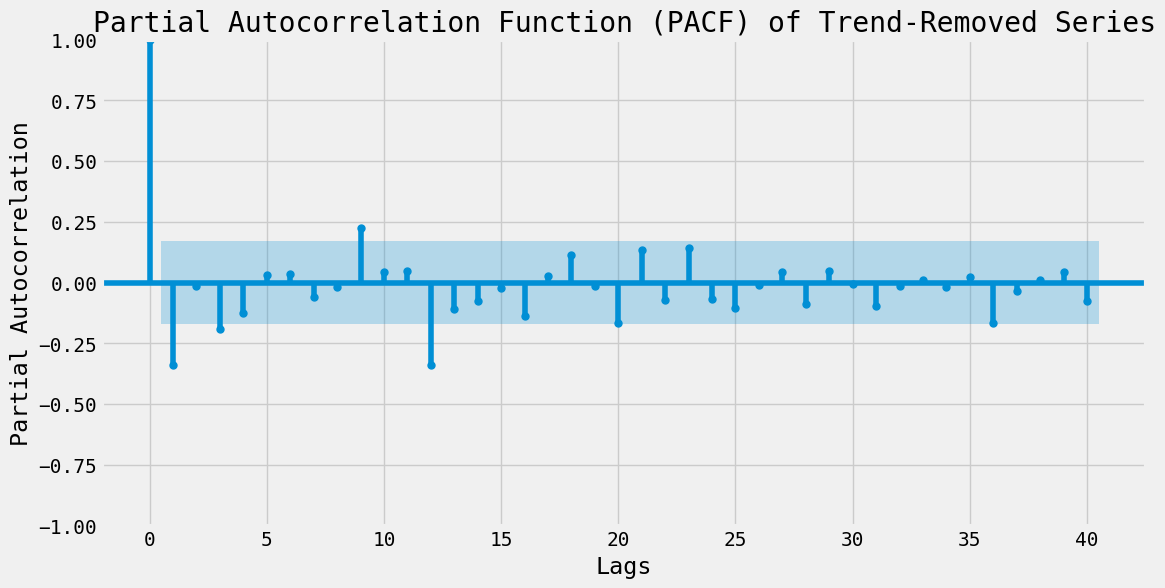

In [ ]:
plt.figure(figsize=(12, 6))
plot_pacf(trend_remove, ax=plt.gca(), lags=40)
plt.title('Partial Autocorrelation Function (PACF) of Trend-Removed Series')
plt.xlabel('Lags')
plt.ylabel('Partial Autocorrelation')
plt.grid(True)
plt.show()

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
ARIMA?

In [ ]:
AR_model = ARIMA(passengers_log,order=(1,1,0))
AR_model

In [ ]:
dir(AR_model)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setitem__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_check_kwargs',
 '_clone_from_init_kwds',
 '_conditional_sum_squares',
 '_data_attr',
 '_fit_collinear',
 '_fit_zeros',
 '_fixed_params',
 '_fixed_params_index',
 '_forecasts_error_partial_derivatives',
 '_formula_max_endog',
 '_free_params_index',
 '_get_exog_names',
 '_get_extension_time_varying_matrices',
 '_get_index_label_loc',
 '_get_index_loc',
 '_get_index_with_final_state',
 '_get_init_kwds',
 '_get_model_names',
 '_get_prediction_index',
 '_handle_data',
 '_has_fixed_params',
 '_hessian_complex_step',
 '_hessian_finite_difference',
 '_hessian_oim',
 '_hessian_opg

In [ ]:
AR_Model = AR_model.fit()
AR_Model

### Autoregressive (AR) Model

An AR model predicts future values based on past values. The 'p' parameter indicates the number of lag observations to include in the model. We can infer 'p' from the PACF plot, looking for significant spikes. For an AR model, we usually fit it to the stationary series.

In [ ]:
AR_Model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  144
Model:                 ARIMA(1, 1, 0)   Log Likelihood                 120.299
Date:                Mon, 30 Mar 2026   AIC                           -236.598
Time:                        10:59:43   BIC                           -230.672
Sample:                    01-01-1949   HQIC                          -234.190
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2054      0.093      2.204      0.028       0.023       0.388
sigma2         0.0109      0.002      6.050      0.000       0.007       0.014
===================================================================================
Ljung-Box (L1) (Q):                   0.13   Jarque-Bera (JB):                 6.19
Prob(Q):                              0.71   Prob(JB):                         0.05
Heteroskedasticity (H):               1.16   Skew:                             0.19
Prob(H) (two-sided):                  0.60   Kurtosis:                         2.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#moving average

In [ ]:
MA_model=ARIMA(passengers_log,order=(0,1,1))
MA_model_results = MA_model.fit()
MA_model_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  144
Model:                 ARIMA(0, 1, 1)   Log Likelihood                 121.363
Date:                Mon, 30 Mar 2026   AIC                           -238.725
Time:                        10:59:43   BIC                           -232.800
Sample:                    01-01-1949   HQIC                          -236.317
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ma.L1          0.2768      0.104      2.668      0.008       0.073       0.480
sigma2         0.0107      0.002      6.286      0.000       0.007       0.014
===================================================================================
Ljung-Box (L1) (Q):                   0.15   Jarque-Bera (JB):                 6.45
Prob(Q):                              0.69   Prob(JB):                         0.04
Heteroskedasticity (H):               1.16   Skew:                             0.22
Prob(H) (two-sided):                  0.61   Kurtosis:                         2.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#ARIMA MODEL

In [ ]:
Arima_model=ARIMA(passengers_log,order=(1,1,1))
Arima_model_results=Arima_model.fit()
Arima_model_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  144
Model:                 ARIMA(1, 1, 1)   Log Likelihood                 124.313
Date:                Mon, 30 Mar 2026   AIC                           -242.626
Time:                        10:59:44   BIC                           -233.738
Sample:                    01-01-1949   HQIC                          -239.014
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5773      0.164     -3.516      0.000      -0.899      -0.256
ma.L1          0.8478      0.098      8.687      0.000       0.657       1.039
sigma2         0.0103      0.002      5.991      0.000       0.007       0.014
===================================================================================
Ljung-Box (L1) (Q):                   0.02   Jarque-Bera (JB):                 5.94
Prob(Q):                              0.90   Prob(JB):                         0.05
Heteroskedasticity (H):               1.07   Skew:                             0.04
Prob(H) (two-sided):                  0.82   Kurtosis:                         2.00
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#sarimax_model

In [ ]:
SARIMAX_model = ARIMA(passengers_log, order=(1, 1, 1), seasonal_order=(1,1,1,12))
SARIMAX_model_results = SARIMAX_model.fit()
SARIMAX_model_results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                    SARIMAX Results                                     
========================================================================================
Dep. Variable:                                y   No. Observations:                  144
Model:             ARIMA(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                 245.152
Date:                          Mon, 30 Mar 2026   AIC                           -480.304
Time:                                  10:59:51   BIC                           -465.928
Sample:                              01-01-1949   HQIC                          -474.462
                                   - 12-01-1960                                         
Covariance Type:                            opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.1694      0.212      0.797      0.425      -0.247       0.586
ma.L1         -0.5640      0.184     -3.065      0.002      -0.925      -0.203
ar.S.L12      -0.0994      0.197     -0.504      0.614      -0.485       0.287
ma.S.L12      -0.4970      0.210     -2.366      0.018      -0.909      -0.085
sigma2         0.0013      0.000      8.460      0.000       0.001       0.002
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                 3.50
Prob(Q):                              0.91   Prob(JB):                         0.17
Heteroskedasticity (H):               0.61   Skew:                            -0.01
Prob(H) (two-sided):                  0.11   Kurtosis:                         3.80
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

#TRAIN AND TEST

In [ ]:
train = passengers_log[:120]
test = passengers_log[120:]

In [ ]:
 train.head()

,0
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791


In [ ]:
test.tail()

,0
1960-08-01,6.406880
1960-09-01,6.230481
1960-10-01,6.133398
1960-11-01,5.966147
1960-12-01,6.068426


In [ ]:
test.head()

,0
1959-01-01,5.886104
1959-02-01,5.834811
1959-03-01,6.006353
1959-04-01,5.981414
1959-05-01,6.040255


In [ ]:
train.tail()

,0
1958-08-01,6.224558
1958-09-01,6.001415
1958-10-01,5.883322
1958-11-01,5.736572
1958-12-01,5.820083


#FORECASTING

In [ ]:
optimal_model = ARIMA(train,order = (1,1,1),seasonal_order=(1,1,1,12))
optimal_model_results = optimal_model.fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
optimal_model_results.forecast?

In [ ]:
type(test)

pandas.core.series.Series

In [ ]:
test.index

DatetimeIndex(['1959-01-01', '1959-02-01', '1959-03-01', '1959-04-01',
               '1959-05-01', '1959-06-01', '1959-07-01', '1959-08-01',
               '1959-09-01', '1959-10-01', '1959-11-01', '1959-12-01',
               '1960-01-01', '1960-02-01', '1960-03-01', '1960-04-01',
               '1960-05-01', '1960-06-01', '1960-07-01', '1960-08-01',
               '1960-09-01', '1960-10-01', '1960-11-01', '1960-12-01'],
              dtype='datetime64[ns]', freq='MS')

In [ ]:
forecast=optimal_model_results.forecast(steps=36)

In [ ]:
forecast

,predicted_mean
1959-01-01,5.856277
1959-02-01,5.809288
1959-03-01,5.955498
1959-04-01,5.928446
1959-05-01,5.955501
1959-06-01,6.124398
1959-07-01,6.236331
1959-08-01,6.243385
1959-09-01,6.070860
1959-10-01,5.937831


In [ ]:
# The original code produced a SyntaxError because 'signal_only' was treated as a positional argument after the keyword argument 'step=1'.
# Additionally, 'signal_only' is not a valid parameter for the get_forecast method.
# The line below will cause a NameError if 'signal_only' is not defined elsewhere.
# If you intended to get the forecast values, you should use the steps parameter only, as done in cell 'nJpGgSVRVyJj'.
# If you wanted to get the prediction intervals, that was correctly done in cell 'zAaIdGJhXCng'.

# To demonstrate a corrected call that would get a single-step forecast, assuming 'signal_only' was meant to be a parameter:
# If get_forecast had a 'signal_only' parameter and it was meant to be True:
# optimal_model_results.get_forecast(steps=1, signal_only=True)

# However, since 'signal_only' is not a parameter, the correct way to get a single-step forecast is:
# forecast_one_step = optimal_model_results.forecast(steps=1)
# Or, to get the forecast and its intervals:
# prediction_one_step_interval = optimal_model_results.get_forecast(steps=1)
# print(prediction_one_step_interval.summary_frame())

In [ ]:
predicition_interval = optimal_model_results.get_forecast(steps=36)

In [ ]:
predicition_interval.summary_frame()

y,mean,mean_se,mean_ci_lower,mean_ci_upper
1959-01-01,5.856277,0.037334,5.783103,5.929451
1959-02-01,5.809288,0.044884,5.721316,5.897259
1959-03-01,5.955498,0.050168,5.857171,6.053824
1959-04-01,5.928446,0.054741,5.821155,6.035736
1959-05-01,5.955501,0.058923,5.840013,6.070988
1959-06-01,6.124398,0.062820,6.001272,6.247523
1959-07-01,6.236331,0.066488,6.106017,6.366645
1959-08-01,6.243385,0.069963,6.106259,6.380511
1959-09-01,6.070860,0.073274,5.927245,6.214475
1959-10-01,5.937831,0.076442,5.788008,6.087654


In [ ]:
predicition_intervals=predicition_interval.summary_frame()
predicition_intervals

y,mean,mean_se,mean_ci_lower,mean_ci_upper
1959-01-01,5.856277,0.037334,5.783103,5.929451
1959-02-01,5.809288,0.044884,5.721316,5.897259
1959-03-01,5.955498,0.050168,5.857171,6.053824
1959-04-01,5.928446,0.054741,5.821155,6.035736
1959-05-01,5.955501,0.058923,5.840013,6.070988
1959-06-01,6.124398,0.062820,6.001272,6.247523
1959-07-01,6.236331,0.066488,6.106017,6.366645
1959-08-01,6.243385,0.069963,6.106259,6.380511
1959-09-01,6.070860,0.073274,5.927245,6.214475
1959-10-01,5.937831,0.076442,5.788008,6.087654


In [ ]:
lower_bound = predicition_intervals['mean_ci_lower']
upper_bound = predicition_intervals['mean_ci_upper']

# CONVERTING LOG TO ORIGINAL STATE

In [ ]:
train_original = np.exp(train)
test_original = np.exp(test)
forecast_original = np.exp(forecast)
lower_bound_original = np.exp(lower_bound)
upper_bound_original = np.exp(upper_bound)

In [ ]:
fig,ax = plt.subplots(figsize=(14,5))
sns.lineplot(x=train_original.index,y=train_original.values,color='black',label='train')
sns.lineplot(x=test_original.index,y=test_original.values,color='green',label='test')
sns.lineplot(x=forecast_original.index,y=forecast_original,color='violet',label='FORECAST')
ax.fill_between(forecast_original.index, lower_bound_original, upper_bound_original, color='purple', alpha=0.2)
plt.xlabel("MONTH/YEAR")
plt.ylabel("passengers count")
plt.title("prediction performance of SARIMAX model")

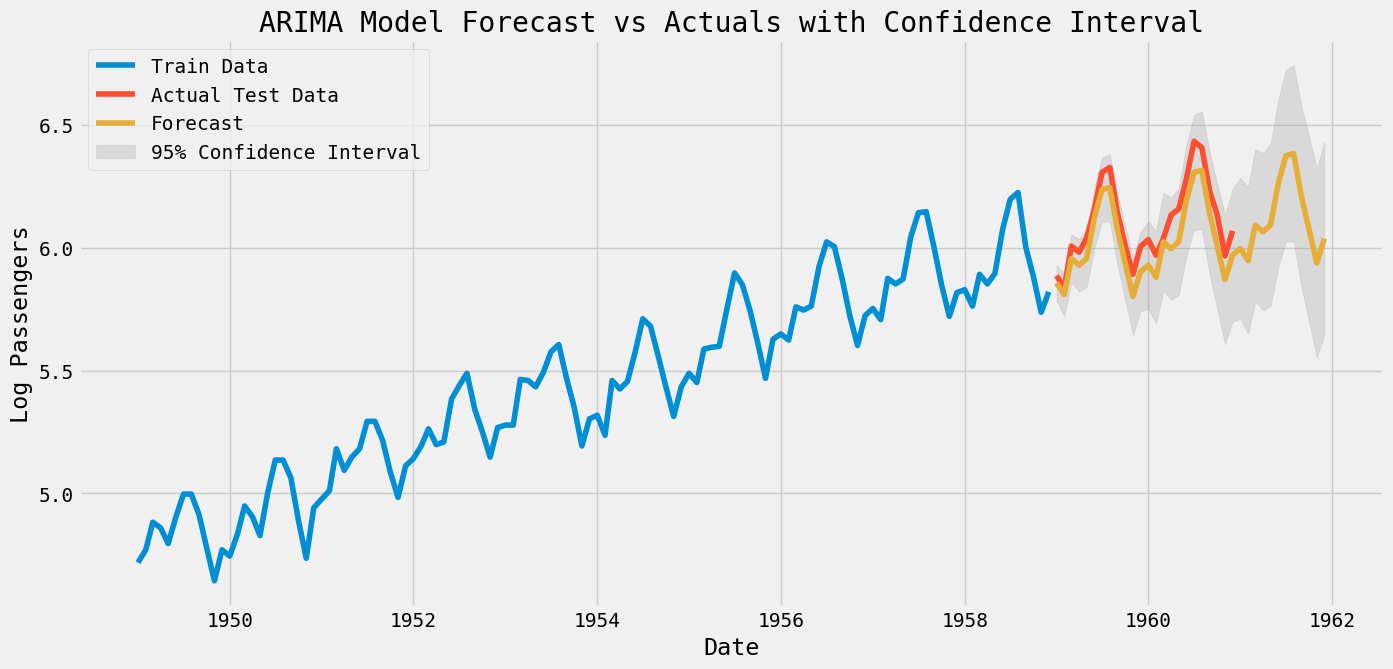

In [ ]:
plt.figure(figsize=(15, 7))
plt.plot(train.index, train, label='Train Data')
plt.plot(test.index, test, label='Actual Test Data')
plt.plot(forecast.index, forecast, label='Forecast')
plt.fill_between(forecast.index, lower_bound, upper_bound, color='gray', alpha=0.2, label='95% Confidence Interval')
plt.title('ARIMA Model Forecast vs Actuals with Confidence Interval')
plt.xlabel('Date')
plt.ylabel('Log Passengers')
plt.legend()
plt.grid(True)
plt.show()

This plot shows the training data, the actual test data (the values the model did not see during training), and the forecasted values generated by your SARIMAX model. This allows for a visual inspection of how well your model's predictions align with the real values.